# Эксперимент с масштабированием Breast Cancer

Цель этапа - проверить, как `StandardScaler` и `MinMaxScaler` влияют на Logistic Regression на полностью числовом датасете.

In [1]:
from pathlib import Path
import sys
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"
RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

import pandas as pd
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler

from experiment_utils import (
    calculate_binary_metrics,
    load_breast_cancer_data,
    save_figure,
    save_results,
    split_breast_cancer_features_target,
)

POSITIVE_LABEL = "malignant"
TEST_SIZE = 0.2
RANDOM_STATE = 42

def positive_proba(model, X, positive_label=POSITIVE_LABEL):
    classifier = model.named_steps["classifier"]
    positive_index = list(classifier.classes_).index(positive_label)
    return model.predict_proba(X)[:, positive_index]

def evaluate_pipeline(name, pipeline, X_train, X_test, y_train, y_test):
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_proba = positive_proba(pipeline, X_test)
    metrics = calculate_binary_metrics(y_test, y_pred, y_proba, POSITIVE_LABEL)
    return metrics, pipeline, y_pred, y_proba

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")


In [2]:
df = load_breast_cancer_data()
X, y = split_breast_cancer_features_target(df)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)


## Сравниваемые варианты

Все варианты используют один и тот же train/test split. Импутация и масштабирование выполняются только внутри `Pipeline`.

In [3]:
experiments = {
    "No scaling": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("classifier", LogisticRegression(max_iter=3000, solver="liblinear")),
    ]),
    "StandardScaler": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(max_iter=3000, solver="liblinear")),
    ]),
    "MinMaxScaler": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", MinMaxScaler()),
        ("classifier", LogisticRegression(max_iter=3000, solver="liblinear")),
    ]),
}

rows = []
for preprocessing, pipeline in experiments.items():
    metrics, fitted_model, _, _ = evaluate_pipeline(preprocessing, pipeline, X_train, X_test, y_train, y_test)
    rows.append({
        "Dataset": "Breast Cancer",
        "Experiment": "Scaling",
        "Model": "LogisticRegression",
        "Preprocessing": preprocessing,
        **metrics,
    })

results = pd.DataFrame(rows).round(4)
save_results(results, RESULTS_DIR / "breast_cancer_scaling_results.csv")
results


,Dataset,Experiment,Model,Preprocessing,Accuracy,F1-score,ROC-AUC
0,Breast Cancer,Scaling,LogisticRegression,No scaling,0.9386,0.9114,0.9937
1,Breast Cancer,Scaling,LogisticRegression,StandardScaler,0.9737,0.9639,0.9960
2,Breast Cancer,Scaling,LogisticRegression,MinMaxScaler,0.9649,0.9500,0.9997


## Графики результатов

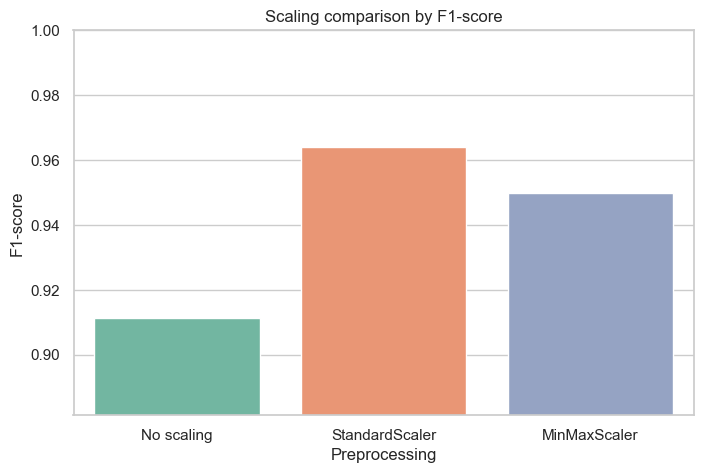

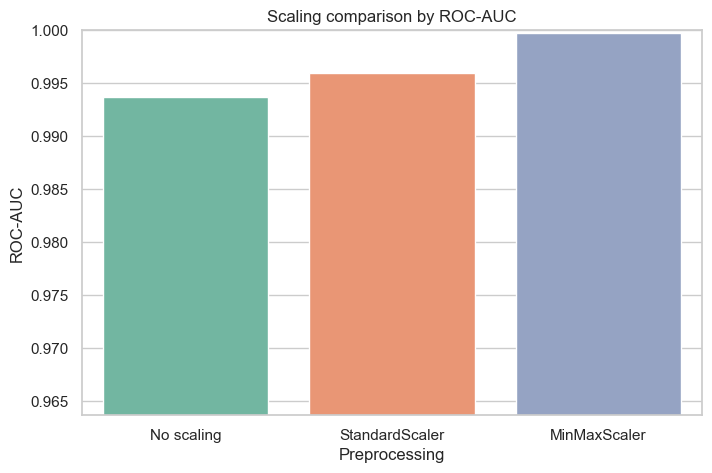

In [4]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results, x="Preprocessing", y="F1-score", hue="Preprocessing", palette="Set2", legend=False)
plt.ylim(max(0, results["F1-score"].min() - 0.03), 1.0)
plt.title("Scaling comparison by F1-score")
plt.xlabel("Preprocessing")
plt.ylabel("F1-score")
save_figure(FIGURES_DIR / "breast_cancer_scaling_f1_comparison.png")
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(data=results, x="Preprocessing", y="ROC-AUC", hue="Preprocessing", palette="Set2", legend=False)
plt.ylim(max(0, results["ROC-AUC"].min() - 0.03), 1.0)
plt.title("Scaling comparison by ROC-AUC")
plt.xlabel("Preprocessing")
plt.ylabel("ROC-AUC")
save_figure(FIGURES_DIR / "breast_cancer_scaling_roc_auc_comparison.png")
plt.show()


## Итоговый вывод

Для Logistic Regression масштабирование полезно, так как признаки Breast Cancer измеряются в разных диапазонах. Разница может быть небольшой из-за высокого базового качества, но стандартизация делает обучение более устойчивым.